# BIRCH (Balanced Iterative Reducing and Clustering using Hierarchies)

**Dataset** : Pendigits (OpenML) - 10 992 echantillons, 16 features, 10 classes  
**Objectif** : Clustering non supervise avec BIRCH, evaluation via ARI, NMI et Silhouette Score  
**Librairies** : scikit-learn, numpy, matplotlib, pandas

In [6]:
import os

# Evite les erreurs/warnings joblib sur certains environnements Windows
os.environ['LOKY_MAX_CPU_COUNT'] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import Birch
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score
)

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

Dataset complet: 10992 echantillons
Sous ensemble 50%: 5496 echantillons
Train: 3847 | Validation: 824 | Test: 825
Classes reelles: 10
Variance expliquee PCA 2D: 0.497
Variance expliquee PCA 10D: 0.967


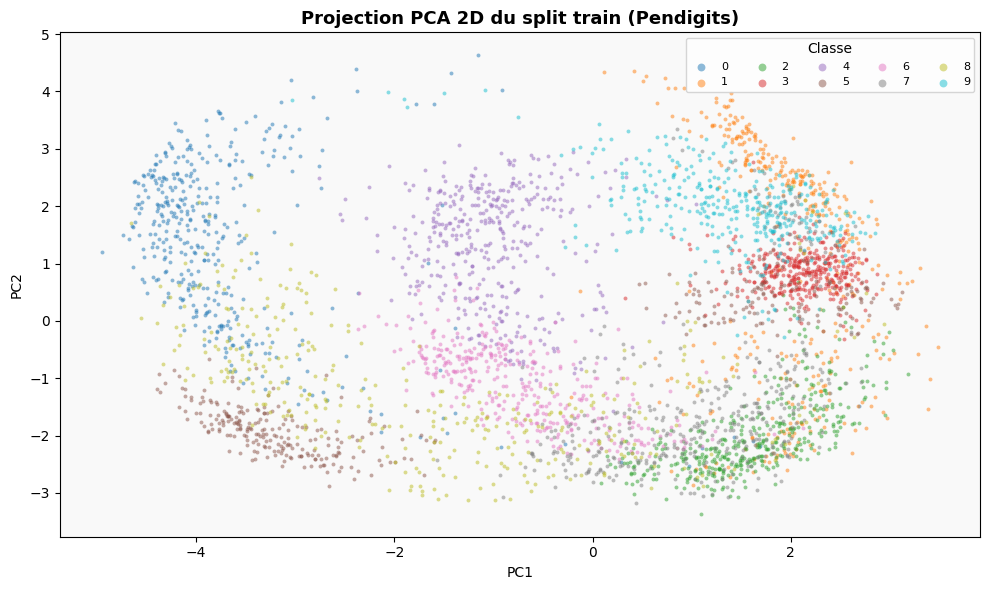

In [7]:
# Chargement des donnees Pendigits
pendigits = fetch_openml('pendigits', version=1, as_frame=False)
X_raw = pendigits.data.astype(float)
y_raw = pendigits.target.astype(int)

# Sous echantillonnage a 50% du dataset complet
X_subset, _, y_subset, _ = train_test_split(
    X_raw, y_raw,
    train_size=0.50,
    stratify=y_raw,
    random_state=42
)

# Split train 70%, validation 15%, test 15%
X_train, X_temp, y_train, y_temp = train_test_split(
    X_subset, y_subset,
    test_size=0.30,
    stratify=y_subset,
    random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(f"Dataset complet: {X_raw.shape[0]} echantillons")
print(f"Sous ensemble 50%: {X_subset.shape[0]} echantillons")
print(f"Train: {X_train.shape[0]} | Validation: {X_val.shape[0]} | Test: {X_test.shape[0]}")
print(f"Classes reelles: {len(np.unique(y_raw))}")

# Standardisation sur train uniquement
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# PCA 2D pour visualisation
pca_2d = PCA(n_components=2, random_state=42)
X_train_pca2 = pca_2d.fit_transform(X_train_scaled)
X_val_pca2 = pca_2d.transform(X_val_scaled)
X_test_pca2 = pca_2d.transform(X_test_scaled)

# PCA 10D pour BIRCH
pca_10d = PCA(n_components=10, random_state=42)
X_train_pca10 = pca_10d.fit_transform(X_train_scaled)
X_val_pca10 = pca_10d.transform(X_val_scaled)
X_test_pca10 = pca_10d.transform(X_test_scaled)

print(f"Variance expliquee PCA 2D: {pca_2d.explained_variance_ratio_.sum():.3f}")
print(f"Variance expliquee PCA 10D: {pca_10d.explained_variance_ratio_.sum():.3f}")

# Visualisation rapide du train en PCA 2D
unique_classes = np.unique(y_train)
colors_true = plt.cm.tab10(np.linspace(0, 1, len(unique_classes)))
label_to_color = {cls: colors_true[i] for i, cls in enumerate(unique_classes)}
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
for cls in unique_classes:
    mask = y_train == cls
    ax.scatter(
        X_train_pca2[mask, 0],
        X_train_pca2[mask, 1],
        c=[label_to_color[cls]],
        label=str(cls),
        s=8,
        alpha=0.5,
        linewidths=0
    )
ax.set_title('Projection PCA 2D du split train (Pendigits)', fontsize=13, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(title='Classe', ncol=5, fontsize=8, markerscale=2, loc='upper right')
ax.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.show()

In [8]:
# Tuning BIRCH sur plusieurs splits aleatoires (Pendigits)
param_grid = {
    'threshold': [0.04, 0.06, 0.08, 0.10, 0.12],
    'branching_factor': [20, 30, 50],
    'n_clusters': [10]
}

# Contraintes conservees
ari_min = 0.75
nmi_min = 0.70

# Validation repetee sur echantillons stratifies
split_seeds = [0, 1, 2]
tuning_sample_size = min(5000, len(X_subset))
tuning_train_fraction = 0.80
pca_tuning_components = 10

print('Intervalles de tuning proposes')
print(f"threshold: {param_grid['threshold']}")
print(f"branching_factor: {param_grid['branching_factor']}")
print(f"n_clusters: {param_grid['n_clusters']}")
print(f"Seeds de validation: {split_seeds}")
print(f"Taille echantillon tuning: {tuning_sample_size}")
print(f"Filtre minimum validation ARI: {ari_min}")
print(f"Filtre minimum validation NMI: {nmi_min}")
print()

def build_tuning_split(seed):
    X_tune, _, y_tune, _ = train_test_split(
        X_subset,
        y_subset,
        train_size=tuning_sample_size,
        stratify=y_subset,
        random_state=seed
    )
    X_tune_train, X_tune_val, y_tune_train, y_tune_val = train_test_split(
        X_tune,
        y_tune,
        train_size=tuning_train_fraction,
        stratify=y_tune,
        random_state=seed
    )

    scaler_tune = StandardScaler()
    X_tune_train_scaled = scaler_tune.fit_transform(X_tune_train)
    X_tune_val_scaled = scaler_tune.transform(X_tune_val)

    pca_tune = PCA(n_components=pca_tuning_components, random_state=seed)
    X_tune_train_pca = pca_tune.fit_transform(X_tune_train_scaled)
    X_tune_val_pca = pca_tune.transform(X_tune_val_scaled)

    return {
        'seed': seed,
        'X_train': X_tune_train_pca,
        'X_val': X_tune_val_pca,
        'y_train': y_tune_train,
        'y_val': y_tune_val
    }


def evaluate_split(name, X, y_true, labels):
    n_clusters = len(set(labels))
    n_noise = 0
    noise_ratio = 0.0

    if len(np.unique(labels)) < 2:
        return {
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_ratio': noise_ratio,
            'ari': np.nan,
            'nmi': np.nan,
            'silhouette': np.nan,
            'valid': False
        }

    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)
    sample_size = min(1200, len(X))
    sil = silhouette_score(X, labels, sample_size=sample_size, random_state=42)

    return {
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_ratio': noise_ratio,
        'ari': ari,
        'nmi': nmi,
        'silhouette': sil,
        'valid': True
    }


def validation_score(metrics, ari_minimum, nmi_minimum):
    if not metrics['valid']:
        return -1e9, False, 'invalid_metrics'

    if metrics['ari'] < ari_minimum or metrics['nmi'] < nmi_minimum:
        soft_score = metrics['ari'] + metrics['nmi']
        return -1e6 + soft_score, False, 'below_thresholds'

    cluster_alignment = 1 - min(abs(metrics['n_clusters'] - 10), 10) / 10
    sil_norm = (metrics['silhouette'] + 1.0) / 2.0
    score = (
        0.40 * metrics['ari']
        + 0.30 * metrics['nmi']
        + 0.20 * sil_norm
        + 0.10 * cluster_alignment
    )
    return score, True, 'eligible'

results = []
total = len(param_grid['threshold']) * len(param_grid['branching_factor']) * len(param_grid['n_clusters'])
trial = 0

for threshold in param_grid['threshold']:
    for branching_factor in param_grid['branching_factor']:
        for n_clusters in param_grid['n_clusters']:
            trial += 1
            params = {
                'threshold': threshold,
                'branching_factor': branching_factor,
                'n_clusters': n_clusters,
                'compute_labels': True
            }

            seed_metrics = []
            seed_scores = []
            seed_eligible_flags = []
            seed_reasons = []

            for seed in split_seeds:
                split_data = build_tuning_split(seed)
                model_train = Birch(**params)
                labels_train_candidate = model_train.fit_predict(split_data['X_train'])

                model_val = Birch(**params)
                labels_val_candidate = model_val.fit_predict(split_data['X_val'])

                metrics_val = evaluate_split('Validation', split_data['X_val'], split_data['y_val'], labels_val_candidate)
                score_val, eligible_val, eligibility_reason = validation_score(metrics_val, ari_min, nmi_min)

                seed_metrics.append(metrics_val)
                seed_scores.append(score_val)
                seed_eligible_flags.append(eligible_val)
                seed_reasons.append(eligibility_reason)

            avg_ari = float(np.nanmean([m['ari'] for m in seed_metrics]))
            avg_nmi = float(np.nanmean([m['nmi'] for m in seed_metrics]))
            avg_sil = float(np.nanmean([m['silhouette'] for m in seed_metrics]))
            avg_clusters = int(round(np.nanmean([m['n_clusters'] for m in seed_metrics])))
            avg_noise_ratio = float(np.nanmean([m['noise_ratio'] for m in seed_metrics]))
            avg_score = float(np.nanmean(seed_scores))
            eligible_val = bool(all(seed_eligible_flags))
            eligibility_reason = 'eligible' if eligible_val else 'below_thresholds_or_invalid'
            avg_metrics = {
                'n_clusters': avg_clusters,
                'n_noise': 0,
                'noise_ratio': avg_noise_ratio,
                'ari': avg_ari,
                'nmi': avg_nmi,
                'silhouette': avg_sil,
                'valid': all(m['valid'] for m in seed_metrics)
            }

            results.append({
                'trial': trial,
                'params': params,
                'score_val': avg_score,
                'eligible_val': eligible_val,
                'eligibility_reason': eligibility_reason,
                'metrics_val': avg_metrics,
                'seed_metrics': seed_metrics,
                'seed_scores': seed_scores,
                'seed_reasons': seed_reasons
            })

            status = 'eligible' if eligible_val else 'rejete'
            print(
                f"Essai {trial}/{total} | score moyen={avg_score:.4f} | "
                f"ARI={avg_ari:.4f} | NMI={avg_nmi:.4f} | SIL={avg_sil:.4f} | statut={status} | "
                f"threshold={threshold} | branching_factor={branching_factor}"
            )

eligible_results = [r for r in results if r['eligible_val']]
if len(eligible_results) > 0:
    results_sorted = sorted(eligible_results, key=lambda x: x['score_val'], reverse=True)
    print(f"Combinaisons eligibles: {len(eligible_results)} sur {len(results)}")
else:
    results_sorted = sorted(results, key=lambda x: x['score_val'], reverse=True)
    print('Aucune combinaison ne passe le filtre ARI/NMI, selection sur score de secours.')

best_result = results_sorted[0]
best_params = best_result['params']

print('Top 5 combinaisons validation')
for rank, item in enumerate(results_sorted[:5], start=1):
    m = item['metrics_val']
    p = item['params']
    elig = 'eligible' if item['eligible_val'] else item['eligibility_reason']
    print(
        f"{rank}. score={item['score_val']:.4f} | "
        f"statut={elig} | "
        f"threshold={p['threshold']} | "
        f"branching_factor={p['branching_factor']} | "
        f"n_clusters={p['n_clusters']} | "
        f"clusters={m['n_clusters']} | bruit={m['noise_ratio']:.2%} | "
        f"ARI={m['ari']:.4f} | NMI={m['nmi']:.4f} | SIL={m['silhouette']:.4f}"
    )

print()
print('Meilleure combinaison retenue pour le modele final')
print(best_params)
print()
print('Le test est reserve a la fin et execute dans la cellule finale uniquement.')

Intervalles de tuning proposes
threshold: [0.04, 0.06, 0.08, 0.1, 0.12]
branching_factor: [20, 30, 50]
n_clusters: [10]
Seeds de validation: [0, 1, 2]
Taille echantillon tuning: 5000
Filtre minimum validation ARI: 0.75
Filtre minimum validation NMI: 0.7

Essai 1/15 | score moyen=-999998.7035 | ARI=0.5634 | NMI=0.7330 | SIL=0.2906 | statut=rejete | threshold=0.04 | branching_factor=20
Essai 2/15 | score moyen=-999998.7035 | ARI=0.5634 | NMI=0.7330 | SIL=0.2906 | statut=rejete | threshold=0.04 | branching_factor=30
Essai 3/15 | score moyen=-999998.7035 | ARI=0.5634 | NMI=0.7330 | SIL=0.2906 | statut=rejete | threshold=0.04 | branching_factor=50
Essai 4/15 | score moyen=-999998.7035 | ARI=0.5634 | NMI=0.7330 | SIL=0.2906 | statut=rejete | threshold=0.06 | branching_factor=20
Essai 5/15 | score moyen=-999998.7035 | ARI=0.5634 | NMI=0.7330 | SIL=0.2906 | statut=rejete | threshold=0.06 | branching_factor=30
Essai 6/15 | score moyen=-999998.7035 | ARI=0.5634 | NMI=0.7330 | SIL=0.2906 | statut

In [11]:
# Test final propre: fit sur TRAIN, evaluation sur TEST
if 'best_params' not in globals():
    raise RuntimeError("best_params introuvable. Execute d'abord la cellule 5 (tuning).")

# On force le fit du modele final sur le train uniquement
final_params = dict(best_params)
final_params['compute_labels'] = True

birch_test_final = Birch(**final_params)
birch_test_final.fit(X_train_pca10)
labels_test = birch_test_final.predict(X_test_pca10)

test_metrics = evaluate_split('Test final', X_test_pca10, y_test, labels_test)

print('Test final execute (fit sur train, predict sur test).')
print('Hyperparametres utilises pour le test final')
print(final_params)
print(
    f"Resume test -> ARI={test_metrics['ari']:.4f} | "
    f"NMI={test_metrics['nmi']:.4f} | SIL={test_metrics['silhouette']:.4f}"
)

Test final execute (fit sur train, predict sur test).
Hyperparametres utilises pour le test final
{'threshold': 0.12, 'branching_factor': 20, 'n_clusters': 10, 'compute_labels': True}
Resume test -> ARI=0.5955 | NMI=0.7601 | SIL=0.2829


In [12]:
print('=== METRIQUES FINALES ===')
if 'test_metrics' in globals():
    print(f"Test ARI: {test_metrics['ari']:.4f}")
    print(f"Test NMI: {test_metrics['nmi']:.4f}")
    print(f"Test Silhouette: {test_metrics['silhouette']:.4f}")
else:
    print('test_metrics indisponible: execute la cellule 6 avant.')

if 'best_result' in globals() and 'metrics_val' in best_result:
    m = best_result['metrics_val']
    print(f"Validation ARI: {m['ari']:.4f}")
    print(f"Validation NMI: {m['nmi']:.4f}")
    print(f"Validation Silhouette: {m['silhouette']:.4f}")
else:
    print('best_result indisponible: execute la cellule 5 avant.')

=== METRIQUES FINALES ===
Test ARI: 0.5955
Test NMI: 0.7601
Test Silhouette: 0.2829
Validation ARI: 0.5711
Validation NMI: 0.7356
Validation Silhouette: 0.2933


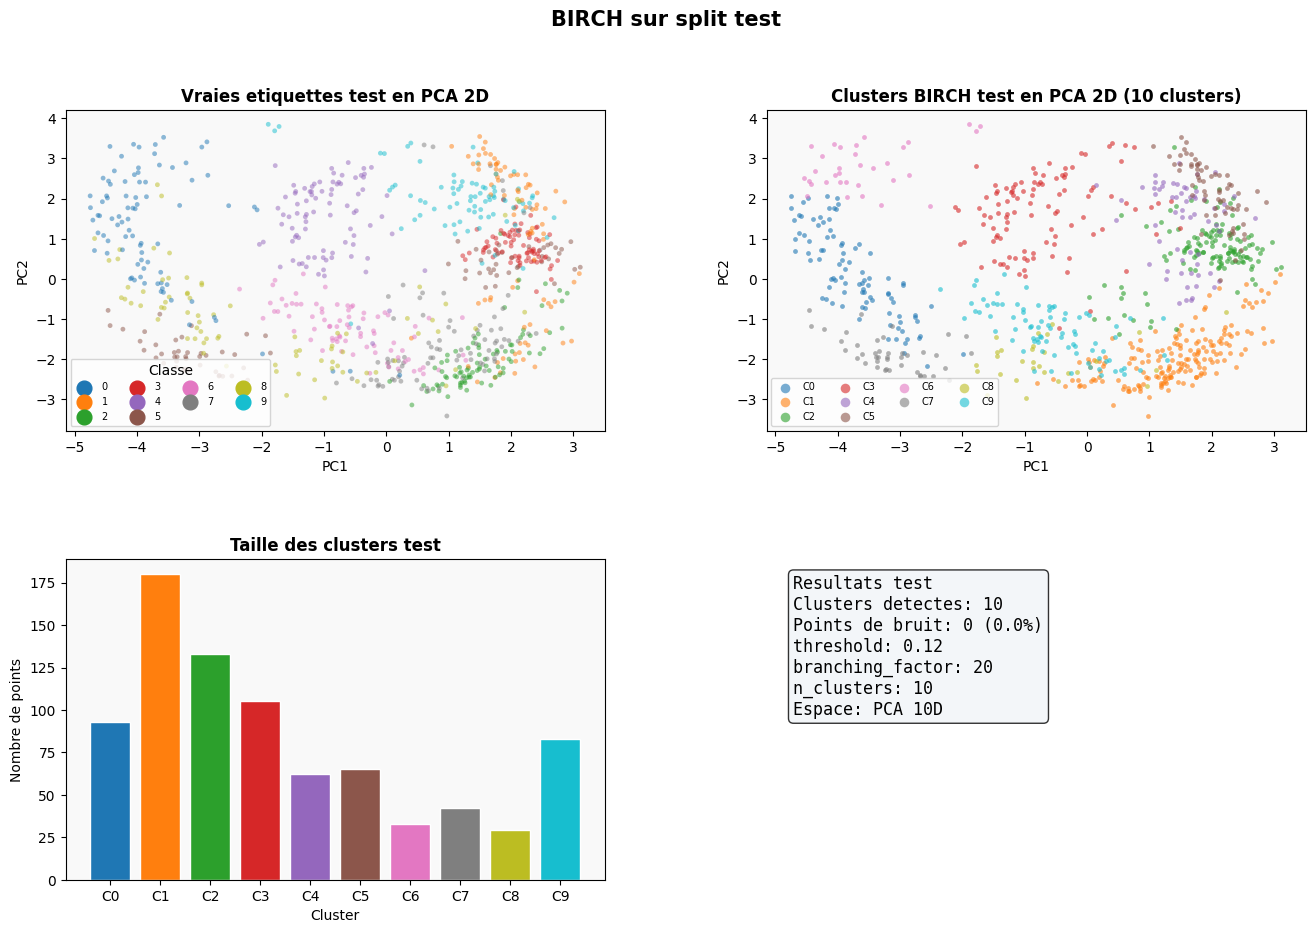

In [10]:
# Visualisation des resultats du split test
if 'labels_test' not in globals():
    print('Les labels du test ne sont pas encore calcules. Execute d abord la cellule de test final.')
else:
    cluster_ids_test, cluster_sizes_test = np.unique(labels_test, return_counts=True)
    n_clusters_test = len(cluster_ids_test)
    n_noise_test = 0
    noise_ratio_test = 0.0

    palette = plt.cm.tab10(np.linspace(0, 1, max(n_clusters_test, 10)))
    color_map = {cid: palette[i % len(palette)] for i, cid in enumerate(cluster_ids_test)}

    point_colors_pred_test = np.array([color_map[l] for l in labels_test])
    point_colors_true_test = np.array([label_to_color[c] for c in y_test])

    fig = plt.figure(figsize=(16, 10), facecolor='white')
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.scatter(X_test_pca2[:, 0], X_test_pca2[:, 1], c=point_colors_true_test, s=12, alpha=0.5, linewidths=0)
    ax1.set_title('Vraies etiquettes test en PCA 2D', fontsize=12, fontweight='bold')
    ax1.set_xlabel('PC1')
    ax1.set_ylabel('PC2')
    ax1.set_facecolor('#f9f9f9')
    for cls in unique_classes:
        ax1.scatter([], [], c=[label_to_color[cls]], label=str(cls), s=50)
    ax1.legend(title='Classe', ncol=4, fontsize=7, markerscale=1.5)

    ax2 = fig.add_subplot(gs[0, 1])
    for cid in cluster_ids_test:
        mask_c = labels_test == cid
        ax2.scatter(
            X_test_pca2[mask_c, 0],
            X_test_pca2[mask_c, 1],
            c=[color_map[cid]],
            s=12,
            alpha=0.6,
            linewidths=0,
            label=f'C{cid}'
        )
    ax2.set_title(f'Clusters BIRCH test en PCA 2D ({n_clusters_test} clusters)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('PC1')
    ax2.set_ylabel('PC2')
    ax2.set_facecolor('#f9f9f9')
    ax2.legend(ncol=4, fontsize=7, markerscale=2)

    ax3 = fig.add_subplot(gs[1, 0])
    bar_colors = [color_map[cid] for cid in cluster_ids_test]
    ax3.bar([f'C{cid}' for cid in cluster_ids_test], cluster_sizes_test, color=bar_colors, edgecolor='white')
    ax3.set_title('Taille des clusters test', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Cluster')
    ax3.set_ylabel('Nombre de points')
    ax3.set_facecolor('#f9f9f9')

    ax4 = fig.add_subplot(gs[1, 1])
    ax4.axis('off')
    metrics_text = (
        f"Resultats test\n"
        f"Clusters detectes: {n_clusters_test}\n"
        f"Points de bruit: {n_noise_test} ({noise_ratio_test:.1%})\n"
        f"threshold: {best_params['threshold']}\n"
        f"branching_factor: {best_params['branching_factor']}\n"
        f"n_clusters: {best_params['n_clusters']}\n"
        f"Espace: PCA 10D"
    )
    ax4.text(
        0.05,
        0.95,
        metrics_text,
        transform=ax4.transAxes,
        fontsize=12,
        verticalalignment='top',
        fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f0f4f8', alpha=0.8)
    )
    ax4.set_facecolor('white')

    plt.suptitle('BIRCH sur split test', fontsize=15, fontweight='bold')
    plt.show()